In [99]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, BayesianRidge
import statsmodels.formula.api as sm
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from mord import LogisticIT
from dmba import classificationSummary, gainsChart, liftChart
from dmba.metric import AIC_score
import seaborn as sns
%matplotlib inline
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score

In [4]:
hr_df=pd.read_csv("hremployee.csv")# Reading in the data.

In [11]:
print(hr_df)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

In [5]:
clean_hr_df=hr_df.dropna()# dropping missing rows

In [13]:
clean_hr_df=clean_hr_df.drop_duplicates() # dropping duplicate

In [57]:
print(clean_hr_df)# There were no rows with missing or duplicate values

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

In [59]:
#Reduce data frame to top 1,000 rows and select columns for regression analysis
hr_df=hr_df.iloc[0:1000]
predictors= ["Age", "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole"]
outcome= "DailyRate"

In [61]:
print(hr_df) # Review the dataset.

     Age Attrition     BusinessTravel  DailyRate              Department  \
0     41       Yes      Travel_Rarely       1102                   Sales   
1     49        No  Travel_Frequently        279  Research & Development   
2     37       Yes      Travel_Rarely       1373  Research & Development   
3     33        No  Travel_Frequently       1392  Research & Development   
4     27        No      Travel_Rarely        591  Research & Development   
..   ...       ...                ...        ...                     ...   
995   43        No      Travel_Rarely        930  Research & Development   
996   27        No      Travel_Rarely        205                   Sales   
997   27       Yes      Travel_Rarely        135  Research & Development   
998   26        No      Travel_Rarely        683  Research & Development   
999   42        No      Travel_Rarely       1147         Human Resources   

     DistanceFromHome  Education   EducationField  EmployeeCount  \
0                  

In [63]:
# Using the dummies function to convert categorical variables into dummy variables.
x=pd.get_dummies(hr_df[predictors], drop_first=True)
y=hr_df[outcome]
#split the dataset
train_x, valid_x, train_y, valid_y= train_test_split(x,y, test_size=0.4, random_state=1)

In [65]:
# run the linear regression function on the training set
hr_lm=LinearRegression()
hr_lm.fit(train_x, train_y)

LinearRegression()

In [67]:
#print coefficients
print(pd.DataFrame({"Predictor": x.columns, "coefficient": hr_lm.coef_}))

            Predictor  coefficient
0                 Age    -2.206041
1   TotalWorkingYears     6.261712
2      YearsAtCompany   -10.443572
3  YearsInCurrentRole    11.116809


In [69]:
# print performance measures (training data)
regressionSummary(train_y, hr_lm.predict(train_x))


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 409.4570
            Mean Absolute Error (MAE) : 354.6044
          Mean Percentage Error (MPE) : -57.0686
Mean Absolute Percentage Error (MAPE) : 85.0087


In [71]:
# Use predict() too make predictions on a new set
hr_lm_pred=hr_lm.predict(valid_x)

result= pd.DataFrame({"Predicted": hr_lm_pred, "Actual": valid_y, "Residual": valid_y- hr_lm_pred})
print(result.head(20))

      Predicted  Actual    Residual
507  778.067601    1176  397.932399
818  818.878289     793  -25.878289
452  818.486610     561 -257.486610
368  810.791816     575 -235.791816
242  872.691804    1411  538.308196
929  819.234699     193 -626.234699
262  812.468233     128 -684.468233
810  884.403868     406 -478.403868
318  824.193829    1220  395.806171
49   785.740657    1229  443.259343
446  764.014087     267 -497.014087
142  893.179824     364 -529.179824
968  815.329668     607 -208.329668
345  821.901182    1309  487.098818
971  906.231273    1405  498.768727
133  835.652336     802  -33.652336
104  881.515966    1040  158.484034
6    801.674515    1324  522.325485
600  882.513122     859  -23.513122
496  830.495123    1343  512.504877


In [73]:
regressionSummary(valid_y, hr_lm.predict(valid_x))


Regression statistics

                      Mean Error (ME) : -53.6427
       Root Mean Squared Error (RMSE) : 394.3170
            Mean Absolute Error (MAE) : 339.4656
          Mean Percentage Error (MPE) : -65.4042
Mean Absolute Percentage Error (MAPE) : 88.7175


In [75]:
from sklearn.preprocessing import StandardScaler
# Check the shape of train_x and valid_x
print("train_x shape:", train_x.shape)
print("valid_x shape:", valid_x.shape)
# code for regularized linear regression
#standardize the data
scaler= StandardScaler()
train_x_scaled= scaler.fit_transform(train_x)
valid_x_scaled=scaler.transform(valid_x)
#Lasso regression
lasso=Lasso(alpha=1)
lasso.fit(train_x_scaled, train_y)
regressionSummary(valid_y, lasso.predict(valid_x_scaled))
# Ridge regression
ridge=Ridge(alpha=1)
ridge.fit(train_x_scaled, train_y)
regressionSummary(valid_y, ridge.predict(valid_x_scaled))
# Bayesian Ridge regression
bayesianRidge= BayesianRidge()
bayesianRidge.fit(train_x_scaled, train_y)
regressionSummary(valid_y, bayesianRidge.predict(valid_x_scaled))

train_x shape: (600, 4)
valid_x shape: (400, 4)

Regression statistics

                      Mean Error (ME) : -53.6581
       Root Mean Squared Error (RMSE) : 394.4187
            Mean Absolute Error (MAE) : 339.6166
          Mean Percentage Error (MPE) : -65.4468
Mean Absolute Percentage Error (MAPE) : 88.7617

Regression statistics

                      Mean Error (ME) : -53.6527
       Root Mean Squared Error (RMSE) : 394.3270
            Mean Absolute Error (MAE) : 339.4841
          Mean Percentage Error (MPE) : -65.4100
Mean Absolute Percentage Error (MAPE) : 88.7233

Regression statistics

                      Mean Error (ME) : -55.3241
       Root Mean Squared Error (RMSE) : 397.1692
            Mean Absolute Error (MAE) : 342.2958
          Mean Percentage Error (MPE) : -66.1526
Mean Absolute Percentage Error (MAPE) : 89.5088


In [77]:
from sklearn.model_selection import KFold, cross_val_score

In [79]:
# Create the model
ridge_model= Ridge(alpha=1.0)
# Define the k-fold cross-validaator
k=5
kf=KFold(n_splits=k, shuffle=True, random_state=42)
# Perform k-fold cross-validation
ridge_scores= cross_val_score(ridge_model, x, y, cv=kf, scoring= "neg_mean_squared_error")
# Convert the scores to positive values and take the square root to get RMSE
ridge_rmse_scores= np.sqrt(-ridge_scores)
# Print the results
print(f"Ridge RMSE scores for each fold: {ridge_rmse_scores}")
print(f"Average Ridge RMSE: {ridge_rmse_scores.mean()}")
print(f"Standard Deviation of Ridge RMSE: {ridge_rmse_scores.std()}")

Ridge RMSE scores for each fold: [389.82709134 416.45539588 421.82303548 398.05564506 398.32531618]
Average Ridge RMSE: 404.89729678807305
Standard Deviation of Ridge RMSE: 12.142326831726393


In [81]:
# Create the model
lasso_model=Lasso(alpha=1.0)
# Define the k-fold cross-validator
k=5
kf=KFold(n_splits=k, shuffle=True, random_state=42)
# perform k-fold cross-validation
lasso_scores= cross_val_score(lasso_model, x, y, cv=kf, scoring= "neg_mean_squared_error")
# Convert the scores to positive values and take the square root to get RMSE
lasso_rmse_scores= np.sqrt(-lasso_scores)
# Print the results
print(f"Lasso RMSE scores for each fold: {lasso_rmse_scores}")
print (f"Average Lasso RMSE: {lasso_rmse_scores.mean()}")
print(f"Standard Deviation of Lasso RMSE: {lasso_rmse_scores.std()}")

Lasso RMSE scores for each fold: [389.87348703 416.41549226 421.75604064 398.05602068 398.42323691]
Average Lasso RMSE: 404.9048555060061
Standard Deviation of Lasso RMSE: 12.093941914986743


In [83]:
print(hr_df.columns)# Checking columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [85]:
#drop columns
new_hr_df=hr_df.drop(columns=[ 'BusinessTravel', 'Department',
       'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
        'TrainingTimesLastYear', 'WorkLifeBalance', 'EducationField', 'DailyRate'])
new_hr_df["Leaving"]= [1 if status == "Yes" else 0 for status in new_hr_df["Attrition"]]
       


In [87]:
# Evaluating new df
print(new_hr_df)
new_hr_df=new_hr_df.drop(columns=["Attrition"])

     Age Attrition  TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  \
0     41       Yes                  8               6                   4   
1     49        No                 10              10                   7   
2     37       Yes                  7               0                   0   
3     33        No                  8               8                   7   
4     27        No                  6               2                   2   
..   ...       ...                ...             ...                 ...   
995   43        No                 20              20                   7   
996   27        No                  6               6                   2   
997   27       Yes                  8               8                   2   
998   26        No                  5               4                   3   
999   42        No                 21              20                   7   

     YearsSinceLastPromotion  YearsWithCurrManager  Leaving  
0            

In [89]:
#partition data
x=new_hr_df.drop(columns=["Leaving"])
y=new_hr_df["Leaving"]
train_x, valid_x, train_y, valid_y= train_test_split(x,y, test_size=0.4, random_state=1)

In [109]:
# fit a logistic regression (set penalty to L2 and C=1e42 to avoid regularization)
logit_reg= LogisticRegression(penalty="l2", C=1e42, solver="liblinear")
logit_reg.fit(train_x,train_y)

print("intercept", logit_reg.intercept_[0])
print(pd.DataFrame({"coeff": logit_reg.coef_[0]}, index=x.columns).transpose())
print("AIC", AIC_score(valid_y, logit_reg.predict(valid_x), df=len(train_x.columns)+1))

intercept -0.29965683427302575
            Age  TotalWorkingYears  YearsAtCompany  YearsInCurrentRole  \
coeff -0.020361          -0.049958        0.052552            -0.13127   

       YearsSinceLastPromotion  YearsWithCurrManager  
coeff                 0.120595             -0.047441  
AIC 453.9631045402889


In [103]:
logit_reg_pred= logit_reg.predict(valid_x)
logit_reg_proba= logit_reg.predict_proba(valid_x)
logit_result= pd.DataFrame({"actual": valid_y,
                            "p(0)": [p[0] for p in logit_reg_proba],
                            "p(1)": [p[1] for p in logit_reg_proba],
                            "predicticted": logit_reg_pred})

In [105]:
# training confusion matrix
classificationSummary(train_y, logit_reg.predict(train_x))
# validation confusion matrix
classificationSummary(valid_y, logit_reg.predict(valid_x))

Confusion Matrix (Accuracy 0.8383)

       Prediction
Actual   0   1
     0 503   0
     1  97   0
Confusion Matrix (Accuracy 0.8250)

       Prediction
Actual   0   1
     0 330   0
     1  70   0


C:\Users\a\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.0
Recall: 0.0
Specificity: 1.0


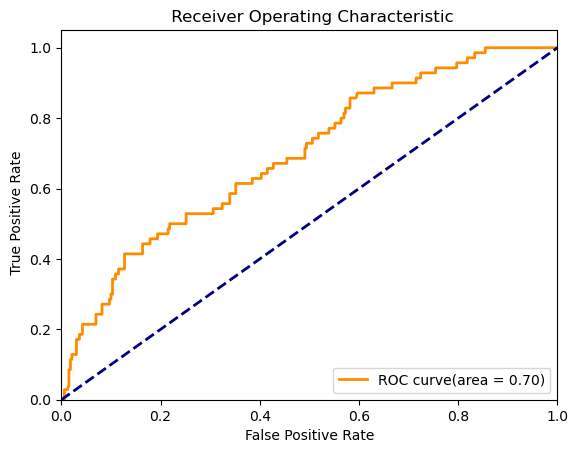

AUC: 0.6951515151515152


In [111]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score

#Precision, Recall and Specificity
precision= precision_score(valid_y, logit_reg_pred)
recall= recall_score(valid_y, logit_reg_pred)

tn, fp, fn, tp = confusion_matrix(valid_y, logit_reg_pred).ravel()
specificity= tn/ (tn+fp)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Specificity: {specificity}")

#Plot ROC Curve and calculate AUC
fpr, tpr, _=roc_curve(valid_y, logit_reg_proba[:,1])
roc_auc= auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve(area = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color= "navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel(" True Positive Rate")
plt.title( " Receiver Operating Characteristic")
plt.legend(loc= "lower right")
plt.show()
print(f"AUC: {roc_auc}")